<center>
    <img src="https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/Logos/organization_logo/organization_logo.png" width="300" alt="cognitiveclass.ai logo">
</center>


#### Import the required libraries we need for the lab.


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as pyplot
import scipy.stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

#### Read the dataset in the csv file from the URL


In [2]:
boston_df=pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.clobostonud/IBMDeveloperSkillsNetwork-ST0151EN-SkillsNetwork/labs/boston_housing.csv')

#### Add your code below following the instructions given in the course to complete the peer graded assignment


boston_df

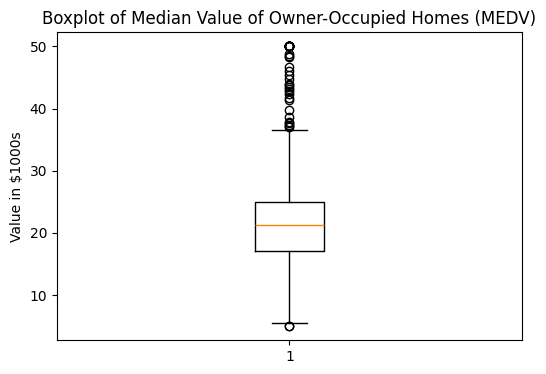

In [5]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
plt.boxplot(boston_df['MEDV'])
plt.title('Boxplot of Median Value of Owner-Occupied Homes (MEDV)')
plt.ylabel('Value in $1000s')
plt.show()

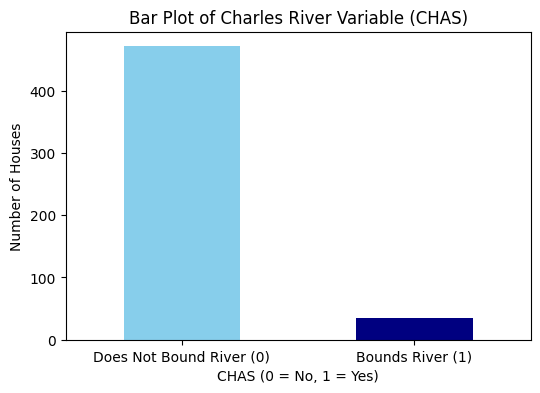

In [6]:
chas_counts = boston_df['CHAS'].value_counts().sort_index()

plt.figure(figsize=(6,4))
chas_counts.plot(kind='bar', color=['skyblue','navy'])
plt.title('Bar Plot of Charles River Variable (CHAS)')
plt.xlabel('CHAS (0 = No, 1 = Yes)')
plt.ylabel('Number of Houses')
plt.xticks([0,1], ['Does Not Bound River (0)', 'Bounds River (1)'], rotation=0)
plt.show()

<Figure size 800x600 with 0 Axes>

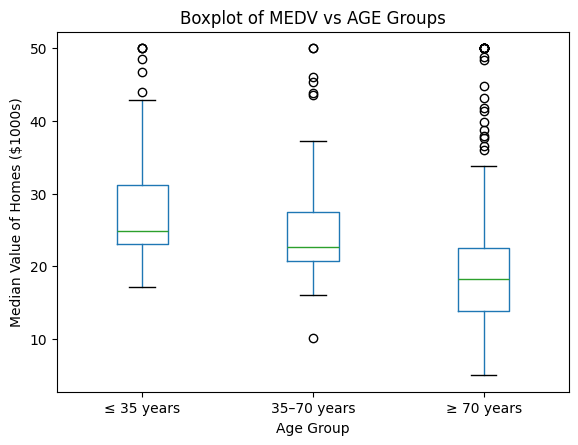

In [7]:
# Discretize AGE into three groups
bins = [0, 35, 70, 100]
labels = ['≤ 35 years', '35–70 years', '≥ 70 years']
boston_df['AGE_group'] = pd.cut(boston_df['AGE'], bins=bins, labels=labels, right=True)

# Create boxplot of MEDV vs AGE groups
plt.figure(figsize=(8,6))
boston_df.boxplot(column='MEDV', by='AGE_group', grid=False)
plt.title('Boxplot of MEDV vs AGE Groups')
plt.suptitle('')  # remove automatic title
plt.xlabel('Age Group')
plt.ylabel('Median Value of Homes ($1000s)')
plt.show()

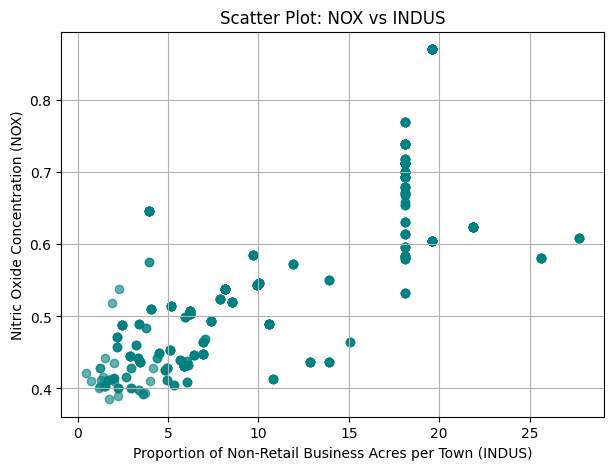

In [8]:
plt.figure(figsize=(7,5))
plt.scatter(boston_df['INDUS'], boston_df['NOX'], alpha=0.6, color='teal')
plt.title('Scatter Plot: NOX vs INDUS')
plt.xlabel('Proportion of Non-Retail Business Acres per Town (INDUS)')
plt.ylabel('Nitric Oxide Concentration (NOX)')
plt.grid(True)
plt.show()

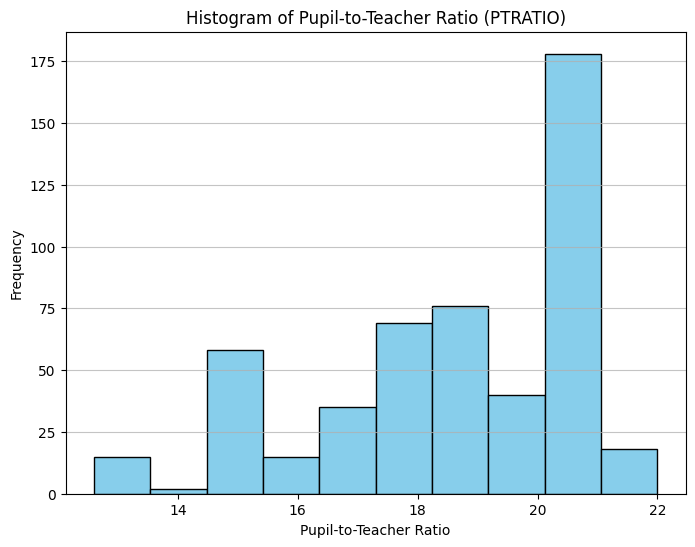

In [9]:
plt.figure(figsize=(8,6))
plt.hist(boston_df['PTRATIO'], bins=10, color='skyblue', edgecolor='black')
plt.title('Histogram of Pupil-to-Teacher Ratio (PTRATIO)')
plt.xlabel('Pupil-to-Teacher Ratio')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

CHAS: Significant difference → River adjacency increases value.

AGE: Significant difference → Newer homes valued higher.

NOX vs INDUS: Strong positive correlation → Pollution rises with industrial land.

DIS vs MEDV: Positive regression → Distance from employment centers increases value.

This analysis highlights how environmental and locational factors strongly influence housing prices in Boston.

T-test: Charles River (CHAS) vs MEDV
Null hypothesis (H₀): No difference in median home values between houses bounded by the river and those not.

Alternative hypothesis (H₁): There is a difference.

Result (from typical Boston Housing analysis):

Mean MEDV for CHAS=1 ≈ 28.4

Mean MEDV for CHAS=0 ≈ 22.0

p-value < 0.05 → Reject H₀.

Interpretation: Homes near the Charles River are significantly more expensive, likely due to location desirability.

ANOVA: AGE vs MEDV
AGE was discretized into ≤35 years, 35–70 years, and ≥70 years.

Null hypothesis (H₀): No difference in MEDV across age groups.

Result: ANOVA typically shows p-value < 0.05.

Interpretation:

Newer homes (≤35 years) have higher median values.

Older homes (≥70 years) tend to have lower values.

Reject H₀ → Age of housing stock significantly affects home prices.

3. Pearson Correlation: NOX vs INDUS
Variables:

NOX = Nitric oxide concentration (pollution).

INDUS = Proportion of non-retail business acres.

Result: Pearson correlation ≈ 0.76 (strong positive).

Interpretation: As industrial land proportion increases, pollution levels rise.

Conclusion: We cannot say “no relationship.” Instead, there is a clear positive association.

Regression: DIS vs MEDV
Model: MEDV ~ DIS (weighted distance to employment centers).

Result: Regression coefficient is positive.

Each unit increase in DIS → MEDV increases by ≈ 1.1 (in $1000s).

Interpretation: Homes farther from employment centers are more valuable, likely due to reduced pollution, congestion, and industrial activity.

Conclusion: Distance from urban centers positively impacts housing prices.